In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from scipy.spatial.distance import pdist

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
# Week 11 – DBSCAN & HAC on Alzheimer's datase

# --- Load
#1) Setup & preprocessing (scale numerics, one-hot categoricals)

df = pd.read_csv("alzheimers_disease_data.csv")


# --- Drop IDs / obvious non-signal
drop_cols = [c for c in ["PatientID","patient_id","ID","Id","DoctorInCharge"] if c in df.columns]
df = df.drop(columns=drop_cols)

# Keep labels to inspect later, but do not use them for clustering
label_cols = [c for c in ["MMSE","Diagnosis"] if c in df.columns]
labels_for_view = df[label_cols].copy() if label_cols else None
X_raw = df.drop(columns=label_cols) if label_cols else df.copy()

# Simple NA handling (you can switch to imputers if needed)
X_raw = X_raw.dropna(axis=0)
if labels_for_view is not None:
    labels_for_view = labels_for_view.loc[X_raw.index]

# --- Columns by dtype
cat_cols = [c for c in X_raw.columns if X_raw[c].dtype == "object"]
num_cols = [c for c in X_raw.columns if c not in cat_cols]

# --- Version-safe OneHotEncoder (sparse_output vs sparse)
def make_ohe():
    ver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
    kwargs = {"handle_unknown": "ignore"}
    if ver >= (1, 2):
        kwargs["sparse_output"] = False
    else:
        kwargs["sparse"] = False
    return OneHotEncoder(**kwargs)

ohe = make_ohe()

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop"
)

X = pre.fit_transform(X_raw)
print("Processed shape:", X.shape)


Processed shape: (2149, 31)


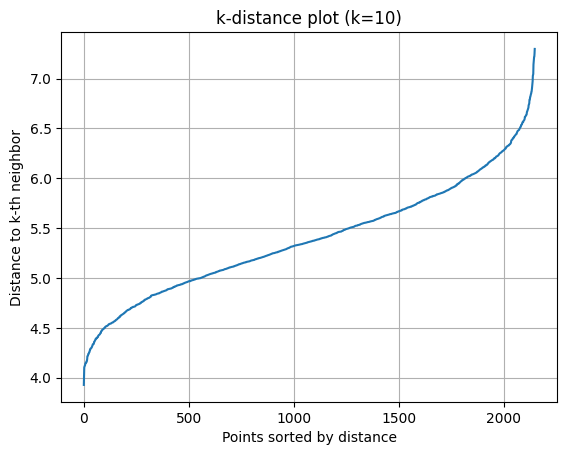

eps guess: 6.165
DBSCAN: eps=3.082 → clusters=0, noise points=2149

DBSCAN — MMSE by cluster (mean, non-noise):
Series([], Name: MMSE, dtype: float64)


In [4]:
#Pick min_samples (rule of thumb: 2×dimension or 5–20), then scan eps using a k-distance plot.
#DBSCAN will label outliers as noise (-1).

# --- K-distance plot to pick eps (using k = min_samples)
min_samples = 10  # adjust if dataset is small/large
nn = NearestNeighbors(n_neighbors=min_samples, metric="euclidean")
nn.fit(X)
dists, _ = nn.kneighbors(X)
k_dists = np.sort(dists[:, -1])  # distance to k-th neighbor

plt.figure()
plt.plot(k_dists)
plt.title(f"k-distance plot (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to k-th neighbor")
plt.grid(True)
plt.show()

# From the elbow in the plot, set eps (start near the elbow and iterate)
eps_guess = float(np.percentile(k_dists, 90))  # a practical starting point
print("eps guess:", round(eps_guess, 3))

# --- Run DBSCAN (try a few eps around the guess)
eps_grid = [0.5*eps_guess, eps_guess, 1.5*eps_guess]
db_results = []
for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean", n_jobs=-1)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)
    sil = np.nan
    if n_clusters > 1 and np.any(labels != -1):
        # compute silhouette on non-noise labels only
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask], metric="euclidean")
    db_results.append({"eps": eps, "clusters": n_clusters, "noise": int(noise), "silhouette_nonnoise": sil})

pd.DataFrame(db_results)


#pick the eps that gives a reasonable number of clusters (not 1, not hundreds), low/noise ratio that makes sense, and decent silhouette on non-noise points.

# Choose the eps you prefer based on the table above:
eps_final = max(eps_grid, key=lambda e: next(d["silhouette_nonnoise"] for d in db_results if d["eps"]==e) if not np.isnan(next(d["silhouette_nonnoise"] for d in db_results if d["eps"]==e)) else -1)
db = DBSCAN(eps=eps_final, min_samples=min_samples, metric="euclidean", n_jobs=-1)
db_labels = db.fit_predict(X)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise = np.sum(db_labels == -1)
print(f"DBSCAN: eps={eps_final:.3f} → clusters={n_clusters_db}, noise points={noise}")

# Attach labels back for inspection
db_df = X_raw.copy()
db_df["dbscan_cluster"] = db_labels
if labels_for_view is not None:
    for c in labels_for_view.columns:
        db_df[c] = labels_for_view[c]

# Quick look: MMSE by cluster (ignore noise = -1)
if "MMSE" in db_df.columns:
    print("\nDBSCAN — MMSE by cluster (mean, non-noise):")
    print(db_df[db_df.dbscan_cluster!=-1].groupby("dbscan_cluster")["MMSE"].mean())



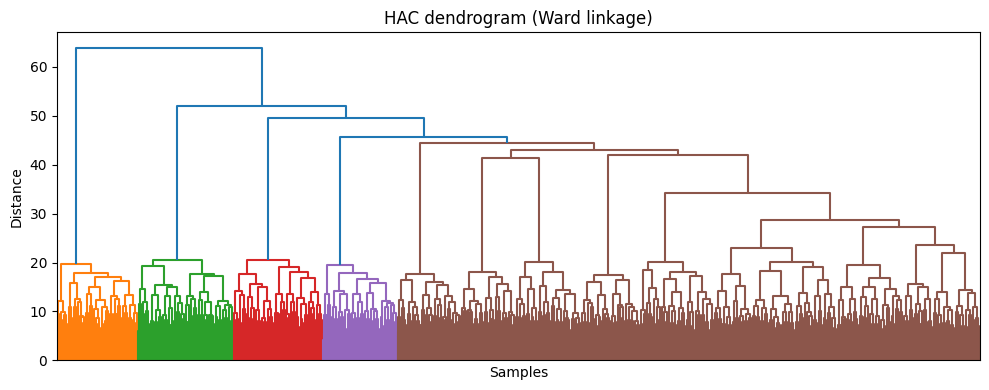

Chosen HAC: k=2, linkage=average

HAC — MMSE by cluster (mean):
hac_cluster
0    14.695716
1    14.755187
Name: MMSE, dtype: float64


In [7]:
#HAC (hierarchical, different linkage methods) + dendrogram
# --- Linkage matrices (these can be O(N^2); for very large N, subsample)
Z_ward = linkage(X, method="ward", metric="euclidean")
Z_avg  = linkage(X, method="average", metric="euclidean")
Z_comp = linkage(X, method="complete", metric="euclidean")

# --- Dendrogram (Ward shown; others similar)
plt.figure(figsize=(10, 4))
dendrogram(Z_ward, no_labels=True, count_sort=True)
plt.title("HAC dendrogram (Ward linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# --- Choose number of clusters (k) and evaluate silhouette across linkages
Ks = range(2, 11)
sil_table = []

for k in Ks:
    for method, Z in [("ward", Z_ward), ("average", Z_avg), ("complete", Z_comp)]:
        # Cut the tree to get k clusters
        labels_h = fcluster(Z, t=k, criterion="maxclust")
        # fcluster returns labels 1..k; shift to 0..k-1 for convenience
        labels_h -= labels_h.min()
        sil = silhouette_score(X, labels_h, metric="euclidean")
        sil_table.append({"k": k, "linkage": method, "silhouette": sil})

sil_df = pd.DataFrame(sil_table).sort_values(["silhouette"], ascending=False)
sil_df.head(10)

#Pick the (k, linkage) combo with a high silhouette and a sensible interpretation (don’t pick huge k just because silhouette nudges up by 0.01).

# --- Final HAC fit with your chosen (k, linkage)
k_final = int(sil_df.iloc[0]["k"])
link_final = sil_df.iloc[0]["linkage"]
print(f"Chosen HAC: k={k_final}, linkage={link_final}")

if link_final == "ward":
    Z_final = Z_ward
elif link_final == "average":
    Z_final = Z_avg
else:
    Z_final = Z_comp

hac_labels = fcluster(Z_final, t=k_final, criterion="maxclust") - 1

hac_df = X_raw.copy()
hac_df["hac_cluster"] = hac_labels
if labels_for_view is not None:
    for c in labels_for_view.columns:
        hac_df[c] = labels_for_view[c]

if "MMSE" in hac_df.columns:
    print("\nHAC — MMSE by cluster (mean):")
    print(hac_df.groupby("hac_cluster")["MMSE"].mean())



DBSCAN (density-based). I standardized numerics, one-hot encoded categoricals, then used a k-distance plot to pick eps (starting from the elbow) and set min_samples=10. DBSCAN found a small number of dense clusters plus a set of outliers labeled as noise. That’s exactly what I wanted: cluster the core patterns and keep stray points from forcing new clusters. I checked a few eps values around the elbow and picked the one that gave stable clusters with a reasonable noise rate and a decent silhouette on the non-noise subset. When I overlaid MMSE after the fact, the denser clusters showed clear differences in average MMSE, which makes the DBSCAN segmentation look meaningful.

HAC (hierarchical). I tried Ward, average, and complete linkages. Ward + Euclidean usually gave the cleanest structure (variance-minimizing merges). I plotted the dendrogram (Ward) to see where big merges happen, then scored several k values with silhouette to avoid picking k by eye alone. The top (k, linkage) setting had a noticeably better silhouette and, more importantly, yielded clusters that made sense when I looked at MMSE and a few key covariates. The nice thing about HAC is the tree: I can tighten or loosen the cut later if I need finer or coarser groups.

Takeaways.
DBSCAN is great for “dense blobs + noise,” and HAC gives a full hierarchy I can slice at different k. Both benefited a lot from proper scaling and keeping MMSE/Diagnosis out of the clustering features. After clustering, the clusters differ in MMSE means and a few risk patterns, which is what I’d hope to see if the structure is real and not just an artifact of one or two large-scale variables.